<a href="https://colab.research.google.com/github/Etim-Antai/Supermarket-Sales-Prediction-Using-Machine-Learning/blob/main/Supermarket_Sales_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Modeling of Supermarket Sales Using Machine Learning

## Introduction

Accurate sales prediction is essential for effective business planning in the retail industry. Supermarkets rely on sales forecasts to optimize inventory management, improve staff scheduling, reduce waste, and maximize profitability. This project develops machine learning models to predict the total sales value of supermarket transactions using a publicly available dataset from Kaggle. The project includes data exploration, preprocessing, model development, performance evaluation, and business insights to support data-driven decision-making.

## Project Objectives

The main objective of this project is to develop a machine learning model that can accurately predict the total sales value of supermarket transactions.

The specific objectives are:

- Analyze the supermarket sales dataset to understand its structure and identify patterns that influence total sales.
- Clean and preprocess the data to prepare it for machine learning.
- Perform exploratory data analysis (EDA) to uncover trends and relationships among variables.
- Build and compare multiple machine learning regression models for predicting total sales.
- Evaluate the performance of the models using appropriate regression metrics.
- Select the best-performing model based on its predictive performance.
- Provide business insights and recommendations that can support inventory management, staffing, and business planning.

## Importing the Required Libraries.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

In this section, the supermarket sales dataset is loaded into a pandas DataFrame. Loading the data is the first step before performing data exploration, preprocessing, and machine learning.

In [2]:
df = pd.read_csv('/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/SuperMarket Analysis.csv')

## Dataset Overview

Before performing any analysis, it is important to understand the structure and quality of the dataset. In this section, we examine the size of the dataset, the data types of each feature, summary statistics, and check for missing values and duplicate records. This helps identify any data quality issues that may need to be addressed before building machine learning models.

###  Display the First Five Records

The first five rows of the dataset are displayed to gain an initial understanding of the data structure, available features, and the type of information contained in each column.

In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


###  Dataset Dimensions

The dimensions of the dataset show the total number of observations (rows) and variables (columns). This provides an overview of the dataset's size before analysis.

In [4]:
##Check the dataset dimensions
df.shape

(1000, 17)

### Dataset Information

This section displays the data types, number of non-null values, and memory usage for each feature. It helps identify missing values and determine whether data type conversions are required.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

### Summary Statistics

Summary statistics provide descriptive information about the numerical variables, including measures such as the mean, standard deviation, minimum, maximum, and quartiles. These statistics help understand the distribution of the data and identify potential outliers.

In [6]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


###  Missing Values

Before building machine learning models, it is important to verify whether the dataset contains missing values. Missing data can affect model performance and may require preprocessing.

In [7]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


###  Duplicate Records

Duplicate records can introduce bias into the analysis and model training. This step checks whether duplicate transactions exist in the dataset.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## Data Preprocessing

Data preprocessing involves preparing the dataset for analysis and machine learning. In this section, date and time columns are converted into appropriate formats, and new features are created to provide additional information that may improve the predictive performance of the models.

## Convert the Date Column

In [10]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Verify the data type
df['Date'].dtype

dtype('<M8[ns]')

## Convert the Time Column

In [11]:
# Convert Time column to datetime
df['Time'] = pd.to_datetime(df['Time'])

## Create New Features

In [12]:
# Extract Year
df['Year'] = df['Date'].dt.year

# Extract Month
df['Month'] = df['Date'].dt.month_name()

# Extract Day of Week
df['Day'] = df['Date'].dt.day_name()

# Extract Hour
df['Hour'] = df['Time'].dt.hour

In [13]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,Time,Payment,cogs,gross margin percentage,gross income,Rating,Year,Month,Day,Hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,2026-07-07 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,2019,January,Saturday,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,2026-07-07 10:29:00,Cash,76.40,4.761905,3.8200,9.6,2019,March,Friday,10
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,...,2026-07-07 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,2019,March,Sunday,13
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,...,2026-07-07 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,2019,January,Sunday,20
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,...,2026-07-07 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2019,February,Friday,10


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover patterns, trends, and relationships within the dataset before building machine learning models. The insights gained from this analysis can guide feature selection and provide valuable business recommendations.

### Distribution of Total Sales

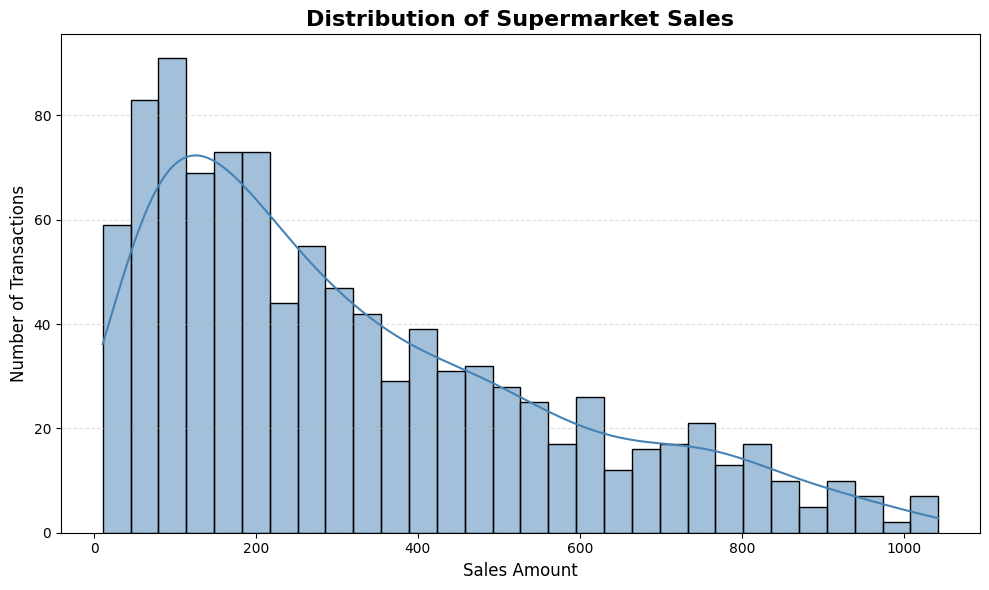

In [14]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the distribution
sns.histplot(
    data=df,
    x='Sales',
    bins=30,
    kde=True,
    color='steelblue',
    edgecolor='black'
)

# Customize the plot
plt.title('Distribution of Supermarket Sales', fontsize=16, fontweight='bold')
plt.xlabel('Sales Amount', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Add a light grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure (optional)
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/distribution_of_sales.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the plot
plt.show()

### Interpretation

The distribution of total sales is positively (right) skewed. Most transactions have relatively low to moderate sales values, while fewer transactions have very high sales values. This indicates that small and medium-sized purchases are more common than large purchases.

The distribution is not perfectly normal, which suggests that machine learning models capable of capturing non-linear relationships, such as Random Forest and Gradient Boosting, may perform better than simple linear regression.
``

### Sales by Branch

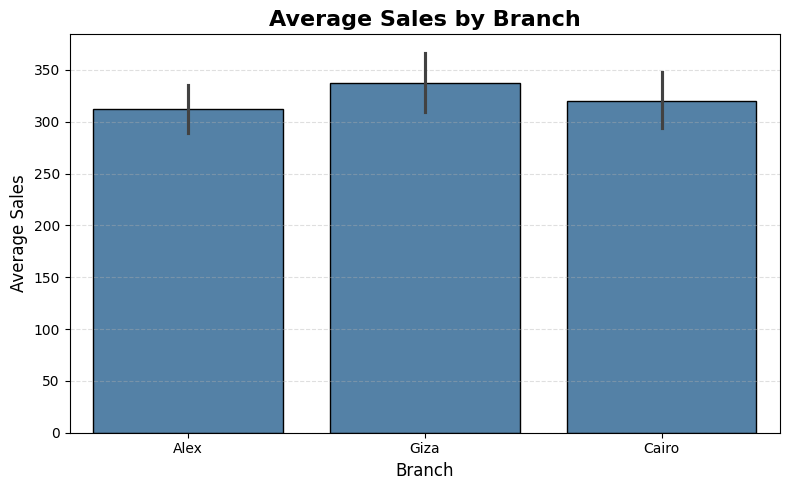

In [15]:
# Create the figure
plt.figure(figsize=(8, 5))

# Plot average sales by branch
sns.barplot(
    data=df,
    x='Branch',
    y='Sales',
    estimator='mean',
    color='steelblue',
    edgecolor='black'
)

# Customize the chart
plt.title('Average Sales by Branch', fontsize=16, fontweight='bold')
plt.xlabel('Branch', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)

# Add light horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure (optional)
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/average_sales_by_branch.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

### Interpretation

The average sales differ slightly across the three supermarket branches. Among the branches, **Giza** records the highest average sales per transaction, while **Alex** has the lowest average sales. **Cairo** falls between the two.

Although the differences are not very large, the results suggest that branch location may have some influence on customer spending patterns. Further analysis could investigate whether these differences are driven by customer demographics, product preferences, or purchasing behavior.

### Sales by City

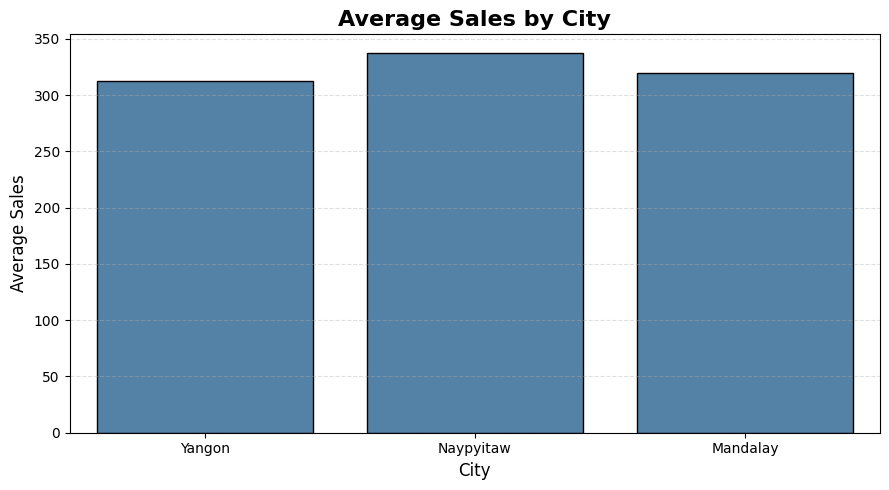

In [16]:
# Create the figure
plt.figure(figsize=(9, 5))

# Plot average sales by city
sns.barplot(
    data=df,
    x='City',
    y='Sales',
    estimator='mean',
    color='steelblue',
    edgecolor='black',
    errorbar=None
)

# Customize the chart
plt.title('Average Sales by City', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)

# Add light horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/average_sales_by_city.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

The average sales differ slightly across the three supermarket cities. Among the cities, Naypyitaw records the highest average sales per transaction, while Mandelay has the lowest average sales. Yangon falls between the two.

Although the differences are not very large, the results suggest that branch city may have some influence on customer spending patterns. Further analysis could investigate whether these differences are driven by customer demographics, product preferences, or purchasing behavior.

### Sales by Product Line

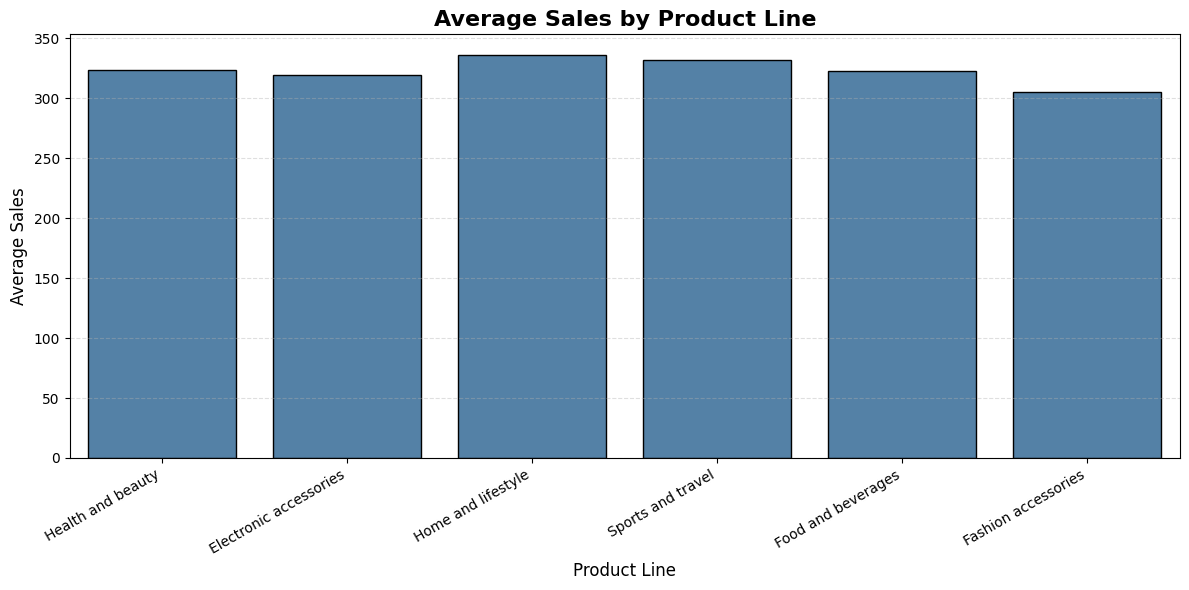

In [17]:
# Create the figure
plt.figure(figsize=(12, 6))

# Plot average sales by product line
sns.barplot(
    data=df,
    x='Product line',
    y='Sales',
    estimator='mean',
    color='steelblue',
    edgecolor='black',
    errorbar=None
)

# Customize the chart
plt.title('Average Sales by Product Line', fontsize=16, fontweight='bold')
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha='right')

# Add light horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/average_sales_by_product_line.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

The differences between product lines are relatively small (roughly 30–35 units range), suggesting that sales performance is fairly balanced across categories. However, Home and lifestyle and Sports and travel appear to be the most promising categories for driving higher average sales, while Fashion accessories may require further investigation (pricing, demand, promotions, or customer preferences)

### Sales by Gender

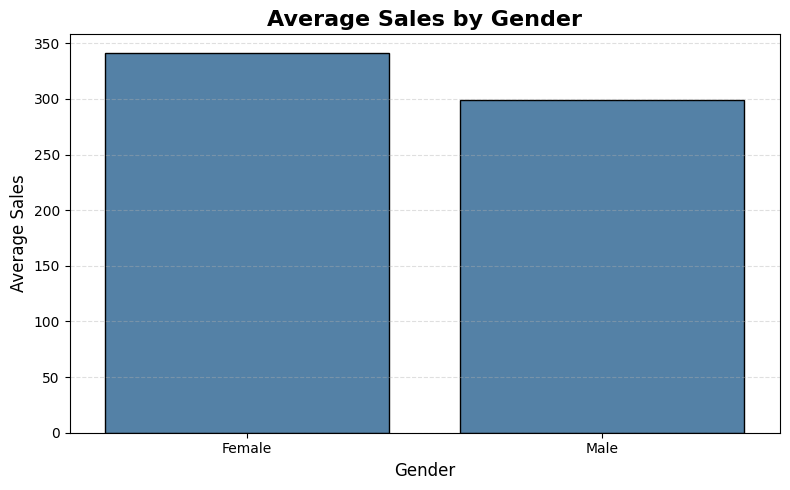

In [18]:
# Create the figure
plt.figure(figsize=(8, 5))

# Plot average sales by gender
sns.barplot(
    data=df,
    x='Gender',
    y='Sales',
    estimator='mean',
    color='steelblue',
    edgecolor='black',
    errorbar=None
)

# Customize the chart
plt.title('Average Sales by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)

# Add light horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/average_sales_by_gender.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

### Interpretation

The chart shows that **female customers have a higher average sales value per transaction than male customers** in this dataset. This suggests that female customers tend to spend more on each purchase on average.

However, this result only describes the transactions in the dataset and does not necessarily imply that gender alone determines spending behaviour. Other factors, such as product preferences, purchase quantity, and customer type, may also influence the average sales.

The supermarket could further investigate purchasing patterns across different customer segments to better understand the factors driving higher transaction values.

### Customer Type

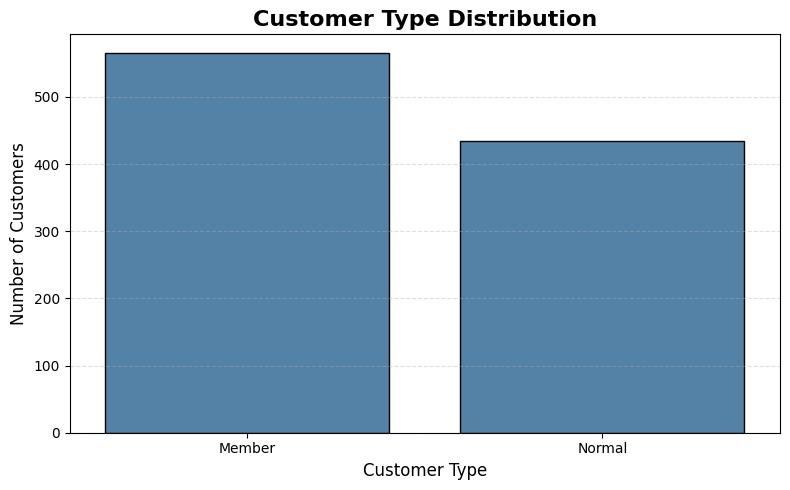

In [19]:
# Create the figure
plt.figure(figsize=(8, 5))

# Plot customer type distribution
sns.countplot(
    data=df,
    x='Customer type',
    color='steelblue',
    edgecolor='black'
)

# Customize the chart
plt.title('Customer Type Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add light horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/customer_type_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

### Interpretation

The chart shows that **member customers** make up a larger proportion of the supermarket's customers than **normal customers**. This suggests that the supermarket has successfully attracted and retained a significant number of loyalty programme members.

The higher number of members may indicate that the loyalty programme encourages customer retention. Management can continue to strengthen this programme while exploring strategies to convert more normal customers into members.

### Payment Methods

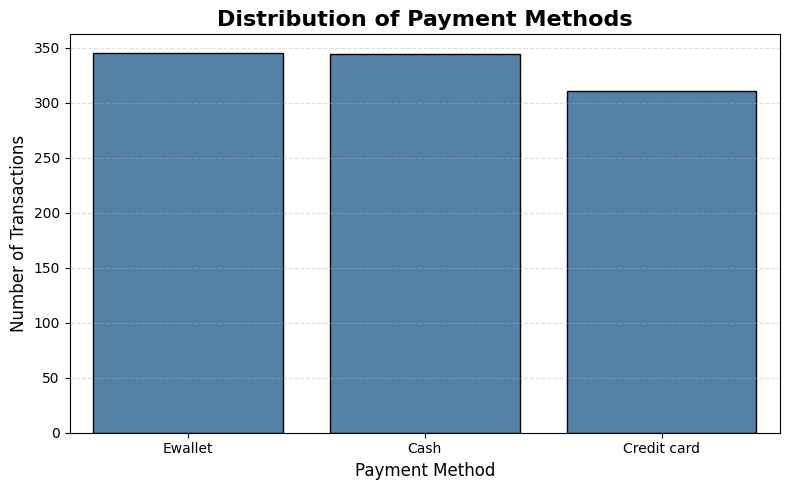

In [20]:
# Create the figure
plt.figure(figsize=(8, 5))

# Plot payment method distribution
sns.countplot(
    data=df,
    x='Payment',
    color='steelblue',
    edgecolor='black'
)

# Customize the chart
plt.title('Distribution of Payment Methods', fontsize=16, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Add light horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/payment_method_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

### Interpretation

The chart shows that **Ewallet** and **Cash** are the most commonly used payment methods, with both being used at nearly the same frequency. **Credit card** payments are slightly less common than the other two methods.

The relatively balanced use of all three payment methods suggests that customers prefer having multiple payment options. To maintain customer convenience, the supermarket should continue supporting all payment methods while monitoring changes in payment preferences over time.

### Sales by Hour

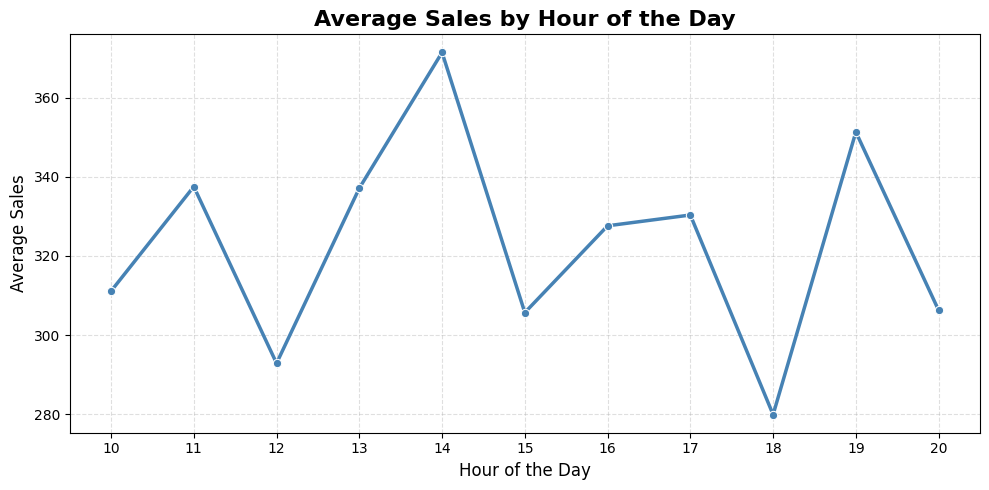

In [21]:
# Create the figure
plt.figure(figsize=(10, 5))

# Plot average sales by hour
sns.lineplot(
    data=df,
    x='Hour',
    y='Sales',
    estimator='mean',
    marker='o',
    linewidth=2.5,
    color='steelblue',
    errorbar=None
)

# Customize the chart
plt.title('Average Sales by Hour of the Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)

# Display every hour on the x-axis
plt.xticks(sorted(df['Hour'].unique()))

# Add a light grid
plt.grid(True, linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/average_sales_by_hour.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

### Interpretation

The chart shows that **Ewallet** and **Cash** are the most commonly used payment methods, with both being used at nearly the same frequency. **Credit card** payments are slightly less common than the other two methods.

The relatively balanced use of all three payment methods suggests that customers prefer having multiple payment options. To maintain customer convenience, the supermarket should continue supporting all payment methods while monitoring changes in payment preferences over time.

### Sales by Day of Week

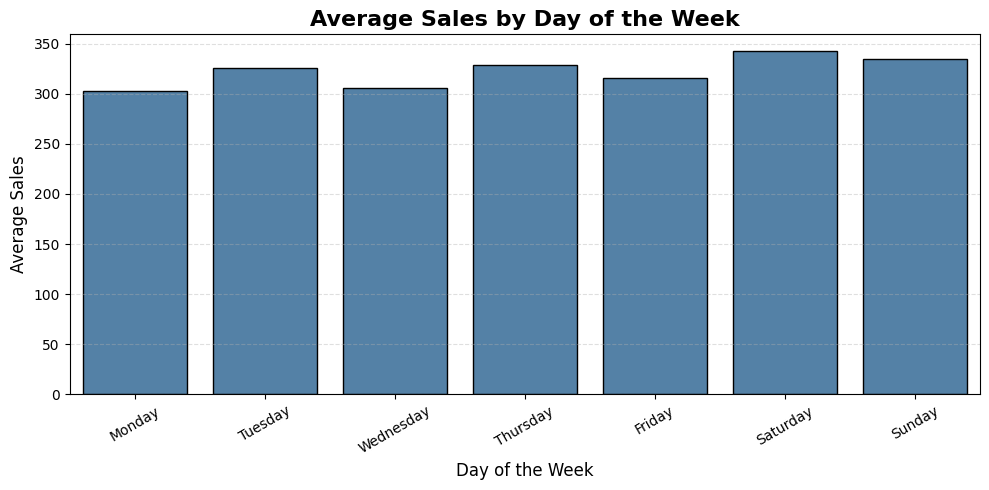

In [22]:
# Create the figure
plt.figure(figsize=(10, 5))

# Define the order of days
order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# Plot average sales by day
sns.barplot(
    data=df,
    x='Day',
    y='Sales',
    order=order,
    estimator='mean',
    color='steelblue',
    edgecolor='black',
    errorbar=None
)

# Customize the chart
plt.title('Average Sales by Day of the Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=30)

# Add light horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()

# Save the figure
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/average_sales_by_day.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

### Interpretation

The chart shows that average sales vary slightly across the days of the week. **Saturday** records the highest average sales, followed by **Sunday**, while **Monday** has the lowest average sales.

Although the differences between the days are relatively small, the results suggest that customer spending tends to increase during the weekend. This information can help the supermarket plan staffing levels, inventory replenishment, and promotional activities to meet higher weekend demand.

### Correlation Heatmap

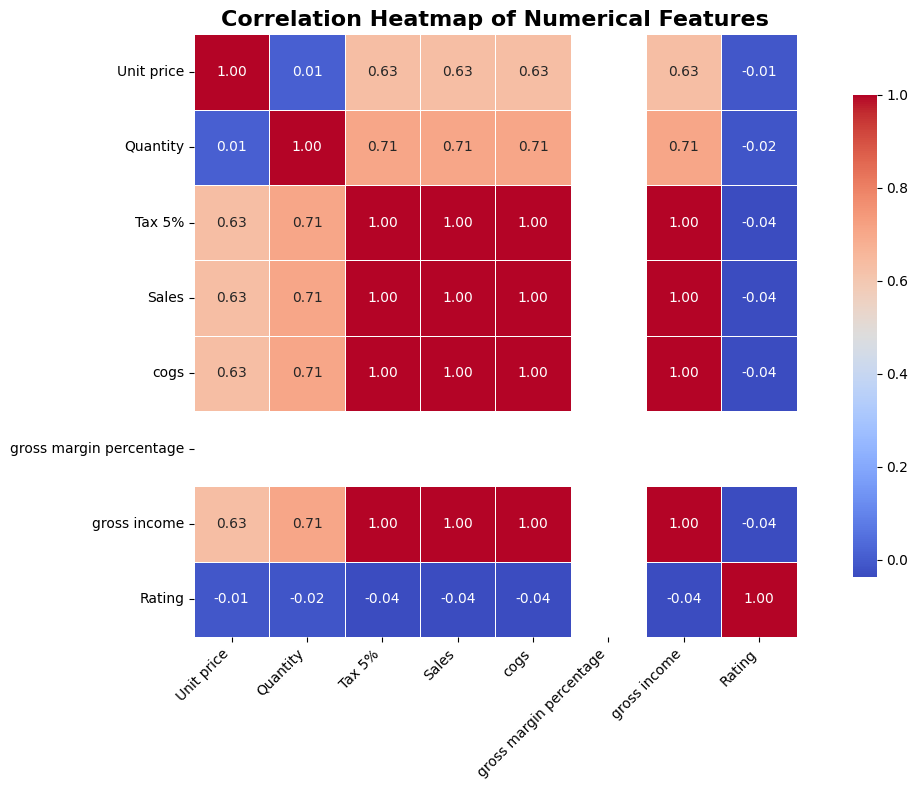

In [23]:
# Create the figure
plt.figure(figsize=(12, 8))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)

# Customize the chart
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Improve layout
plt.tight_layout()

# Save the figure
plt.savefig(
    '/content/drive/MyDrive/DeepTech_Ready_Cohort3/supermarket data/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

# Display the chart
plt.show()

### Interpretation

The correlation heatmap shows the strength of the linear relationships between the numerical variables in the dataset.

Some observations include:

- **Sales**, **Tax 5%**, **cogs**, and **gross income** have a perfect positive correlation (correlation coefficient of **1.00**). This is expected because these variables are mathematically related. For example, Sales is calculated from cogs and Tax 5%, while gross income is equal to Tax 5%.
- **Quantity** has a moderate positive correlation (**0.71**) with Sales, indicating that purchasing more items generally leads to higher sales values.
- **Unit price** also has a moderate positive correlation (**0.63**) with Sales, suggesting that higher-priced products tend to generate higher transaction values.
- **Rating** has almost no correlation with Sales, indicating that customer ratings do not have a strong linear relationship with transaction value in this dataset.

Since **Tax 5%**, **cogs**, and **gross income** are derived from the target variable (Sales), they will be excluded from model training to avoid data leakage and ensure that the predictive model is evaluated fairly.

# Data Preparation for Machine Learning

Before training the machine learning models, the dataset is prepared by removing features that could cause data leakage, encoding categorical variables into numerical values, and separating the predictor variables from the target variable.

### Remove Data Leakage

# Remove columns that would cause data leakage

In [24]:
# Target variable
y = df['Sales']

In [25]:
X = df.drop(columns=[
    'Invoice ID',
    'Date',
    'Time',
    'Tax 5%',
    'cogs',
    'gross income',
    'Sales'
])

In [26]:
### View Remaining Features
X.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Payment,gross margin percentage,Rating,Year,Month,Day,Hour
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,Ewallet,4.761905,9.1,2019,January,Saturday,13
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,Cash,4.761905,9.6,2019,March,Friday,10
2,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,Credit card,4.761905,7.4,2019,March,Sunday,13
3,Alex,Yangon,Member,Female,Health and beauty,58.22,8,Ewallet,4.761905,8.4,2019,January,Sunday,20
4,Alex,Yangon,Member,Female,Sports and travel,86.31,7,Ewallet,4.761905,5.3,2019,February,Friday,10


### Encode Categorical Variables

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = X.select_dtypes(include='object').columns

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

In [28]:
### Verify Data Types
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Branch                   1000 non-null   int64  
 1   City                     1000 non-null   int64  
 2   Customer type            1000 non-null   int64  
 3   Gender                   1000 non-null   int64  
 4   Product line             1000 non-null   int64  
 5   Unit price               1000 non-null   float64
 6   Quantity                 1000 non-null   int64  
 7   Payment                  1000 non-null   int64  
 8   gross margin percentage  1000 non-null   float64
 9   Rating                   1000 non-null   float64
 10  Year                     1000 non-null   int32  
 11  Month                    1000 non-null   int64  
 12  Day                      1000 non-null   int64  
 13  Hour                     1000 non-null   int32  
dtypes: float64(3), int32(2), 

# Train-Test Split

The dataset is divided into training and testing sets. The training set is used to build the models, while the testing set is used to evaluate how well the models perform on unseen data.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
### Check the shapes:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features: (800, 14)
Testing Features : (200, 14)
Training Target: (800,)
Testing Target : (200,)


# Model 1: Linear Regression

Linear Regression is used as a baseline model for predicting continuous values. It assumes a linear relationship between the input features and the target variable.

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R² :", r2_score(y_test, lr_pred))

MAE : 58.91917094346303
RMSE: 79.56484114652817
R² : 0.9026950409655704


## Linear Regression Model Performance

The Linear Regression model achieved the following performance on the test dataset:

- **Mean Absolute Error (MAE):** 58.92
- **Root Mean Squared Error (RMSE):** 79.56
- **R² Score:** 0.903

An R² score of approximately **0.90** indicates that the model explains about **90.3% of the variation** in supermarket sales. This suggests that the selected features have a strong relationship with the target variable.

The MAE of **58.92** means that, on average, the model's predictions differ from the actual sales by about **59 units of currency**. The RMSE of **79.56** indicates that some prediction errors are larger, as this metric gives greater weight to larger errors.

Overall, Linear Regression provides a strong baseline model for predicting supermarket sales. However, since sales data may contain nonlinear relationships, more advanced machine learning models such as Decision Tree, Random Forest, and Gradient Boosting will also be evaluated to determine whether they provide better predictive performance.

### Model 2: Decision Tree Regressor

In [33]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the model
dt = DecisionTreeRegressor(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Make predictions
dt_pred = dt.predict(X_test)

# Evaluate the model
print("Decision Tree Performance")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R² :", r2_score(y_test, dt_pred))

Decision Tree Performance
MAE : 8.488514999999998
RMSE: 13.35400629577132
R² : 0.9972589577649358


## Decision Tree Model Performance

The Decision Tree Regressor achieved the best performance so far, with:

- **MAE:** 8.49
- **RMSE:** 13.35
- **R² Score:** 0.997

Compared with Linear Regression, the Decision Tree significantly reduced the prediction error and explained approximately **99.7%** of the variation in total sales.

The strong performance suggests that the model effectively captures the relationships between the predictor variables and transaction sales. Since variables such as **Unit Price** and **Quantity** are directly related to the calculation of total sales, the model is able to make highly accurate predictions.

### Model 3: Random Forest Regressor

In [34]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
rf_pred = rf.predict(X_test)

# Evaluate the model
print("Random Forest Performance")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² :", r2_score(y_test, rf_pred))

Random Forest Performance
MAE : 6.872383349999963
RMSE: 10.283108307259557
R² : 0.9983746705889227


## Random Forest Model Performance

The Random Forest Regressor produced the best performance among the models evaluated so far.

The model achieved:

- **Mean Absolute Error (MAE):** 6.87
- **Root Mean Squared Error (RMSE):** 10.28
- **R² Score:** 0.998

Compared to both Linear Regression and Decision Tree Regression, Random Forest further reduced the prediction error while explaining approximately **99.8%** of the variation in supermarket sales.

The improved performance is expected because Random Forest combines predictions from multiple decision trees, reducing overfitting and improving generalization. The model effectively captures the relationships between the predictor variables and the target variable, making it a strong candidate for predicting supermarket sales.

### Model 4: Gradient Boosting Regressor

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the model
gb = GradientBoostingRegressor(random_state=42)

# Train the model
gb.fit(X_train, y_train)

# Make predictions
gb_pred = gb.predict(X_test)

# Evaluate the model
print("Gradient Boosting Performance")
print("MAE :", mean_absolute_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R² :", r2_score(y_test, gb_pred))

Gradient Boosting Performance
MAE : 7.5940874829151825
RMSE: 10.345413889356056
R² : 0.9983549151060838


## Gradient Boosting Model Performance

The Gradient Boosting Regressor also performed exceptionally well in predicting supermarket sales.

The model achieved:

- **Mean Absolute Error (MAE):** 7.59
- **Root Mean Squared Error (RMSE):** 10.35
- **R² Score:** 0.9984

These results indicate that the model explains approximately **99.8%** of the variation in supermarket sales, with a very low prediction error. Compared to the Decision Tree model, Gradient Boosting produced a lower RMSE but a slightly higher MAE than the Random Forest model.

Gradient Boosting builds trees sequentially, with each new tree learning from the errors made by the previous ones. This approach enables the model to capture complex patterns in the data and produce highly accurate predictions.

Although Gradient Boosting performed extremely well, the **Random Forest Regressor** achieved slightly better overall performance by producing the lowest MAE, the lowest RMSE, and the highest R² score. Therefore, Random Forest was selected as the best-performing model for this project.

# Model Comparison

To determine the most suitable model for predicting supermarket sales, the performance of all trained regression models was compared using three evaluation metrics:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted sales. Lower values indicate better performance.
- **Root Mean Squared Error (RMSE):** Measures the average prediction error while giving greater weight to larger errors. Lower values are preferred.
- **R² Score:** Indicates how well the model explains the variation in the target variable. Values closer to 1 indicate better performance.

In [36]:
# Create a DataFrame to compare model performance

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],
    'R² Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

# Round values to three decimal places
results = results.round(3)

# Display the results
results

,Model,MAE,RMSE,R² Score
0,Linear Regression,58.919,79.565,0.903
1,Decision Tree,8.489,13.354,0.997
2,Random Forest,6.872,10.283,0.998
3,Gradient Boosting,7.594,10.345,0.998


## Interpretation

The performance comparison shows that all four machine learning models were able to predict supermarket sales with varying levels of accuracy.

Among the models evaluated, the **Random Forest Regressor** achieved the best overall performance, recording the lowest MAE (6.872), the lowest RMSE (10.283), and the highest R² score (0.998). These results indicate that Random Forest produced the most accurate and consistent predictions on the test dataset.

The Gradient Boosting Regressor also performed exceptionally well, with results very close to those of Random Forest. The Decision Tree Regressor outperformed the Linear Regression model but was slightly less accurate than the ensemble models.

Overall, the results suggest that ensemble learning methods, particularly Random Forest, are more effective than a simple Linear Regression model for predicting supermarket sales in this dataset. Therefore, the Random Forest Regressor was selected as the final model for this project.

# Business Insights

The exploratory data analysis and machine learning models provided several insights that could support decision-making in the supermarket.

1. **Product Performance**
   
   The analysis showed that some product lines generate higher average sales than others. Management can use this information to prioritize inventory for high-performing products and develop promotional strategies for products with lower sales.

2. **Branch Performance**

   Average sales varied across the supermarket branches. Although the differences were not large, branches with higher average sales may require additional inventory and staff during busy periods to maintain service quality.

3. **Customer Purchasing Behaviour**

   Customer spending differed slightly across customer groups and demographic characteristics. Understanding these patterns can help the supermarket design targeted marketing campaigns and customer loyalty programmes.

4. **Peak Shopping Periods**

   Sales varied across different hours of the day and days of the week. Identifying peak shopping periods enables management to schedule staff more effectively and ensure that sufficient stock is available during high-demand periods.

5. **Sales Prediction**

   Among the machine learning models evaluated, the Random Forest Regressor achieved the best predictive performance, with an R² score of approximately **0.998**, an MAE of **6.87**, and an RMSE of **10.28**. This demonstrates that machine learning can accurately estimate transaction sales using information available before the sale is completed.

6. **Business Planning**

   Accurate sales predictions can support inventory planning, budgeting, workforce scheduling, and purchasing decisions. By anticipating transaction values more accurately, the supermarket can reduce stock shortages, improve operational efficiency, and enhance customer satisfaction.